2 задание

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

### 1) Нормальное распределение: M[X] = 10, D[X] = 4

In [23]:
# Параметры нормального распределения
MX = 10
DX = 4
SIGMA = np.sqrt(DX)

#создаем объекты распреления
norm_dist = stats.norm(loc=MX, scale=SIGMA) # наше распределение
std_dist = stats.norm(loc=0, scale=1) # стандартное нормальное распределение


точки для графиков

In [24]:
x_values = np.linspace(MX - 4*SIGMA, MX + 4*SIGMA, 1000)
x_values_std = np.linspace(-4, 4, 1000)

print("НОРМАЛЬНОЕ РАСПРЕДЕЛЕНИЕ: X~N(10,4)")
print(f"Математическое ожидание M[X] = {MX}")
print(f"Дисперсия D[X] = {DX}")
print(f"Среднеквадратичное отклонение SIGMA[X] = {SIGMA}")




НОРМАЛЬНОЕ РАСПРЕДЕЛЕНИЕ: X~N(10,4)
Математическое ожидание M[X] = 10
Дисперсия D[X] = 4
Среднеквадратичное отклонение SIGMA[X] = 2.0


Вычисляем требуемые вероятности

In [25]:
prob_less_than_11 = norm_dist.cdf(11)
prob_between_4_and_12 = norm_dist.cdf(12) - norm_dist.cdf(4)
prob_more_than_14 = 1 - norm_dist.cdf(5)

print(f"P(X < 11) = {prob_less_than_11:.4f}")
print(f"P(4 < X < 12) = {prob_between_4_and_12:.4f}")
print(f"P(X > 14) = {prob_more_than_14:.4f}")

P(X < 11) = 0.6915
P(4 < X < 12) = 0.8400
P(X > 14) = 0.9938


4 графика

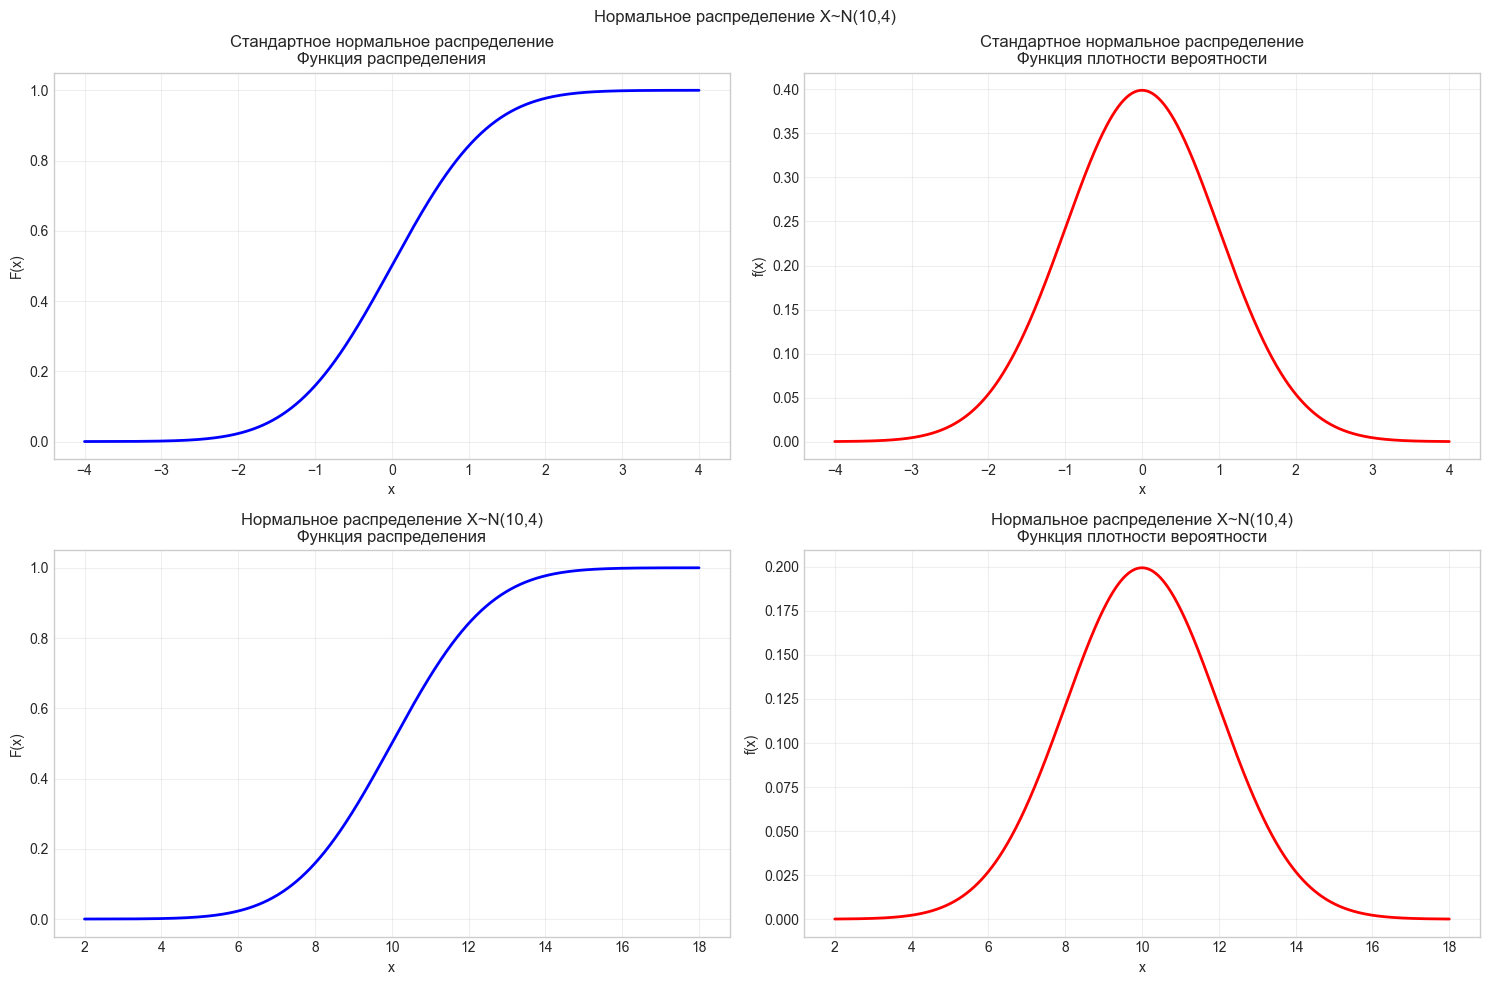

In [26]:
#фигура
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Нормальное распределение X~N(10,4)")

#1 график
axes[0, 0].plot(x_values_std, std_dist.cdf(x_values_std), 'b-', linewidth=2)
axes[0, 0].set_title('Стандартное нормальное распределение\nФункция распределения')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('F(x)')
axes[0, 0].grid(True, alpha=0.3)

#2 график
axes[0, 1].plot(x_values_std, std_dist.pdf(x_values_std), 'r-', linewidth=2)
axes[0, 1].set_title('Стандартное нормальное распределение\nФункция плотности вероятности')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('f(x)')
axes[0, 1].grid(True, alpha=0.3)

#3 график
axes[1, 0].plot(x_values, norm_dist.cdf(x_values), 'b-', linewidth=2)
axes[1, 0].set_title(f"Нормальное распределение X~N({MX},{DX})\nФункция распределения")
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('F(x)')
axes[1, 0].grid(True, alpha=0.3)

#4 график
axes[1, 1].plot(x_values, norm_dist.pdf(x_values), 'r-', linewidth=2)
axes[1, 1].set_title(f"Нормальное распределение X~N({MX},{DX})\nФункция плотности вероятности")
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('f(x)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Вероятности на графиках

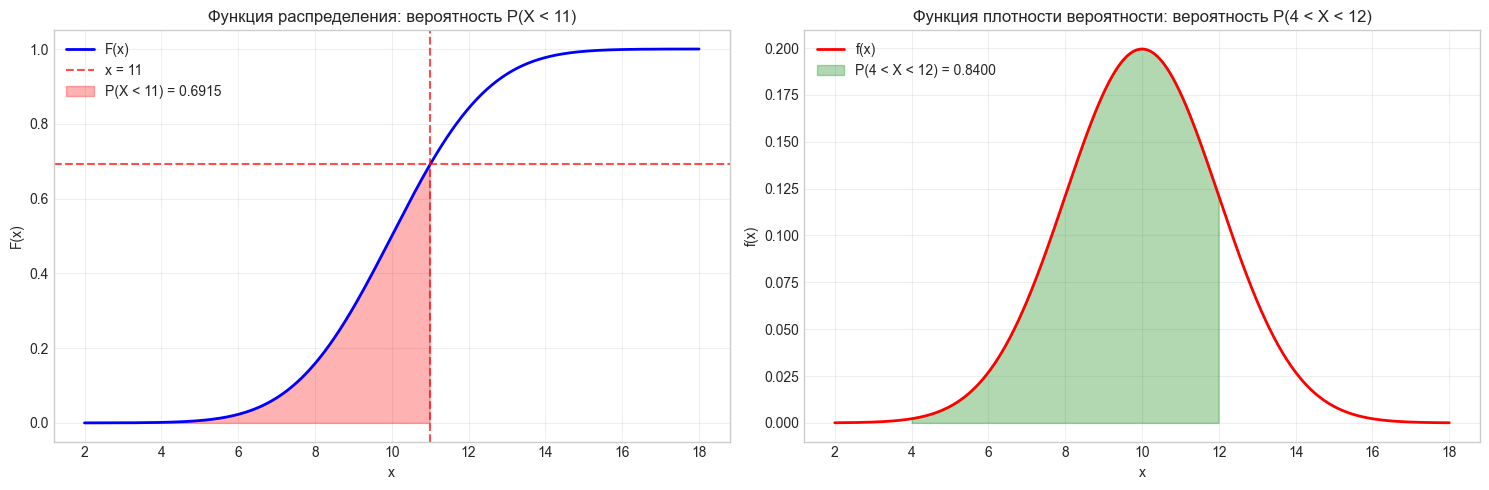

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

#1 график: P(X < 11) на функции распределения
ax1.plot(x_values, norm_dist.cdf(x_values), 'b-', linewidth=2, label='F(x)')
ax1.axvline(x=11, color='r', linestyle='--', alpha=0.7, label='x = 11')
ax1.axhline(prob_less_than_11, color='r', linestyle='--', alpha=0.7)
ax1.fill_between(x_values[x_values < 11], 0, norm_dist.cdf(x_values[x_values < 11]), color='r', alpha=0.3, label=f'P(X < 11) = {prob_less_than_11:.4f}')
ax1.set_title('Функция распределения: вероятность P(X < 11)')
ax1.set_xlabel('x')
ax1.set_ylabel('F(x)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

#2 график: P(4 < X < 12) на функции плотности вероятности
ax2.plot(x_values, norm_dist.pdf(x_values), 'r-', linewidth=2, label='f(x)')
ax2.fill_between(x_values[(x_values > 4) & (x_values < 12)], 0,
                norm_dist.pdf(x_values[(x_values > 4) & (x_values < 12)]),
                alpha=0.3, color='g', label=f'P(4 < X < 12) = {prob_between_4_and_12:.4f}')
ax2.set_title('Функция плотности вероятности: вероятность P(4 < X < 12)')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Правило трех сигм

In [28]:
#вероятности для правил n-сигм
sigma_rules = {
    1: ("μ ± σ (68.3%)", 'lightgreen'),
    2: ("μ ± 2σ (95.4%)", 'lightblue'),
    3: ("μ ± 3σ (99.7%)", 'lightcoral')
}

probabilities = {}
for n in sigma_rules:
    prob = norm_dist.cdf(MX + n*SIGMA) - norm_dist.cdf(MX - n*SIGMA)
    probabilities[n] = prob
    

правила трех сигм на графике

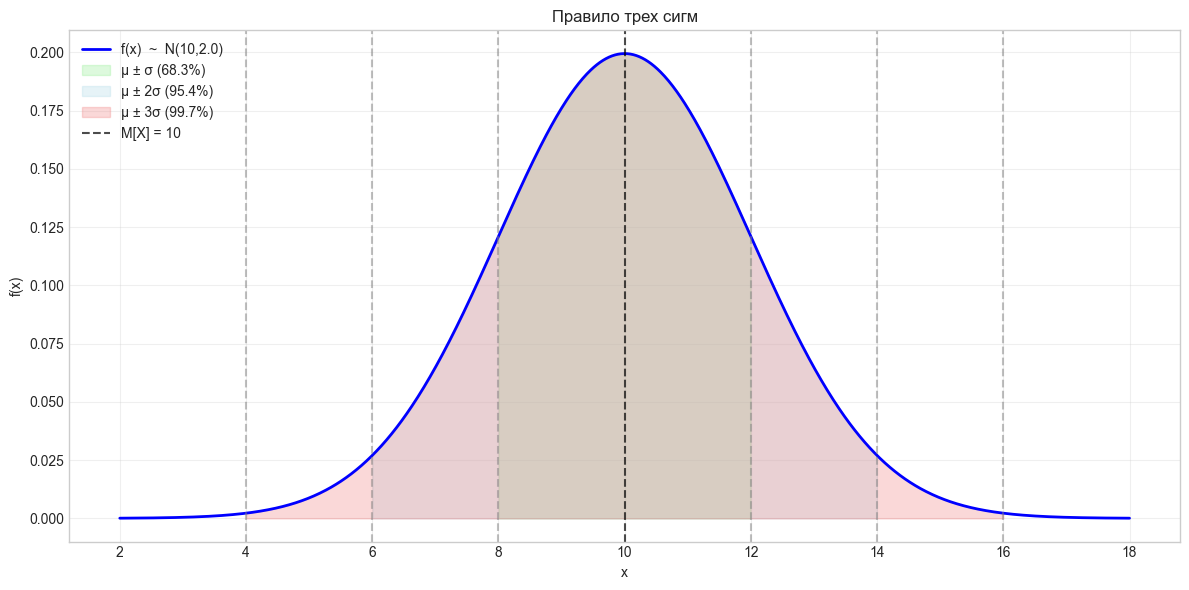

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_values, norm_dist.pdf(x_values), 'b-', linewidth=2, label=f'f(x)  ~  N({MX},{SIGMA})')

#заливаем области для каждого правила
for n, (label, color) in sigma_rules.items():
    x_fill = x_values[(x_values >= MX - n*SIGMA) & (x_values <= MX + n*SIGMA)]
    ax.fill_between(x_fill, 0, norm_dist.pdf(x_fill), color=color, alpha=0.3, label=label)

#вертикальные линии для границ
ax.axvline(x=MX, color='black', linestyle='--', alpha=0.7, label=f'M[X] = {MX}')
for n in [1, 2, 3]:
    ax.axvline(MX + n*SIGMA, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(MX - n*SIGMA, color='gray', linestyle='--', alpha=0.5)

ax.set_title('Правило трех сигм')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Проверка

In [30]:
for n, (label, _) in sigma_rules.items():
    theoretical_prob = [0.6827, 0.9545, 0.9973][n-1]
    actual_prob = probabilities[n]
    print(f"{label:<20} | Теоретическая вероятность: {theoretical_prob:.4f} | Фактическая вероятность: {actual_prob:.4f} | Отклонение: {abs(theoretical_prob - actual_prob):.4f}")

μ ± σ (68.3%)        | Теоретическая вероятность: 0.6827 | Фактическая вероятность: 0.6827 | Отклонение: 0.0000
μ ± 2σ (95.4%)       | Теоретическая вероятность: 0.9545 | Фактическая вероятность: 0.9545 | Отклонение: 0.0000
μ ± 3σ (99.7%)       | Теоретическая вероятность: 0.9973 | Фактическая вероятность: 0.9973 | Отклонение: 0.0000


### 2) Экспоненциальное распределение: M[Y] = 2

In [31]:
# Параметры экспоненциального распределения
MY = 2
LAMBDA = 1/MY
DY = 1/LAMBDA**2
SIGMA_Y = np.sqrt(DY)

#создаем объекты распределения
exp_dist = stats.expon(scale=1 / LAMBDA)

точки для графиков

In [32]:
y_values = np.linspace(0, 10, 1000)

print("ЭКСПОНЕНЦИАЛЬНОЕ РАСПРЕДЕЛЕНИЕ: Y~Exp(0.5)")
print(f"Математическое ожидание M[Y] = {MY}")
print(f"Параметр λ = 1 / M[Y] = {LAMBDA}")
print(f"Дисперсия D[Y] = 1/λ^2 = {DY}")
print(f"Среднеквадратичное отклонение SIGMA[Y] = {SIGMA_Y}")

ЭКСПОНЕНЦИАЛЬНОЕ РАСПРЕДЕЛЕНИЕ: Y~Exp(0.5)
Математическое ожидание M[Y] = 2
Параметр λ = 1 / M[Y] = 0.5
Дисперсия D[Y] = 1/λ^2 = 4.0
Среднеквадратичное отклонение SIGMA[Y] = 2.0


вычисляем вероятности

In [33]:
prob_less_than_3 = exp_dist.cdf(3)
prob_between_1_and_25 = exp_dist.cdf(2.5) - exp_dist.cdf(1)
prob_more_than_2 = 1 - exp_dist.cdf(2)

print(f"P(Y < 3) = {prob_less_than_3:.4f}")
print(f"P(1 < Y < 2.5) = {prob_between_1_and_25:.4f}")
print(f"P(Y > 2) = {prob_more_than_2:.4f}")


P(Y < 3) = 0.7769
P(1 < Y < 2.5) = 0.3200
P(Y > 2) = 0.3679


доп проверка свойств

In [34]:
print("свойства экспоненциального распределения:")
print(f"проврека MY = 1/λ = {LAMBDA} должно быть равно {MY}")
print(f"проверка P(Y > t) = e^(-λt) = {np.exp(-LAMBDA*MY)} должно быть равно {prob_more_than_2}")

свойства экспоненциального распределения:
проврека MY = 1/λ = 0.5 должно быть равно 2
проверка P(Y > t) = e^(-λt) = 0.36787944117144233 должно быть равно 0.36787944117144233


создаем фигуры

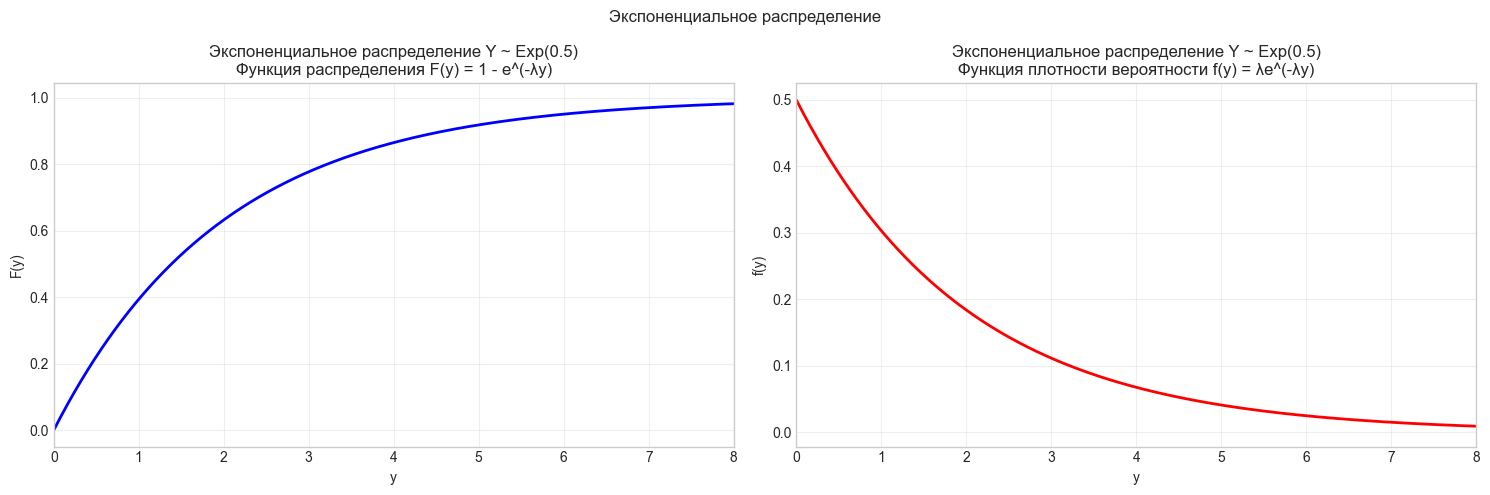

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Экспоненциальное распределение")

#1 график: функция распределения
ax1.plot(y_values, exp_dist.cdf(y_values), 'b-', linewidth=2, label='F(y)')
ax1.set_title(f'Экспоненциальное распределение Y ~ Exp({LAMBDA})\nФункция распределения F(y) = 1 - e^(-λy)')
ax1.set_xlabel('y')
ax1.set_ylabel('F(y)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 8)

#2 график: функция плотности вероятности
ax2.plot(y_values, exp_dist.pdf(y_values), 'r-', linewidth=2, label='f(y)')
ax2.set_title(f'Экспоненциальное распределение Y ~ Exp({LAMBDA})\nФункция плотности вероятности f(y) = λe^(-λy)')
ax2.set_xlabel('y')
ax2.set_ylabel('f(y)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 8)

plt.tight_layout()
plt.show()

вероятности на графиках

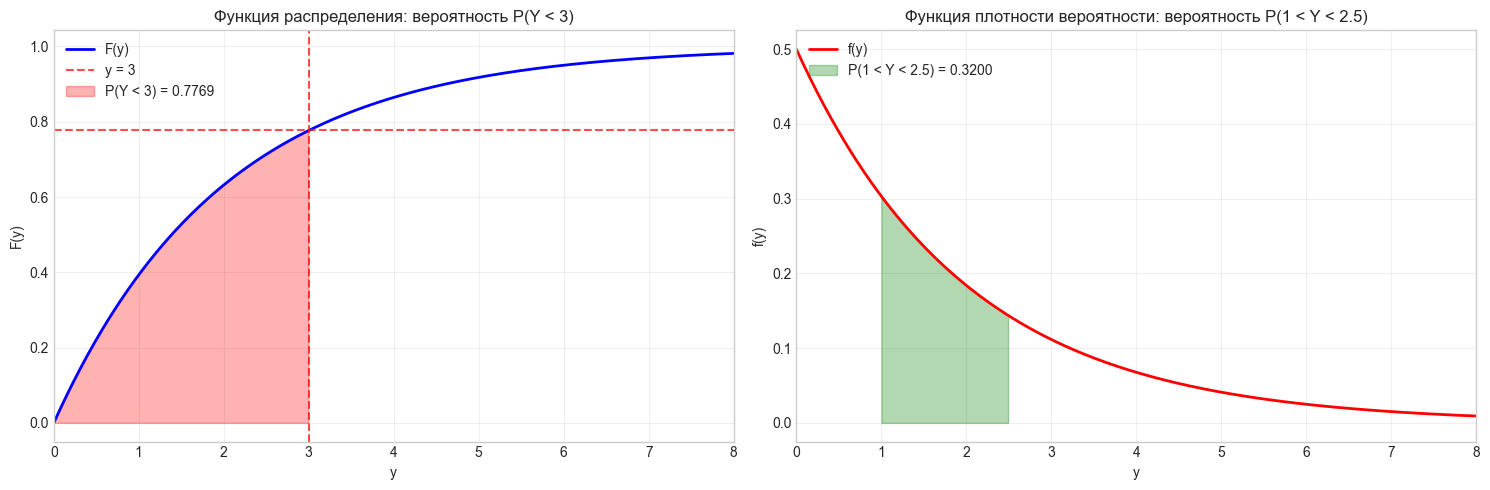

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

#1 график: P(Y < 3) на функции распределения
ax1.plot(y_values, exp_dist.cdf(y_values), 'b-', linewidth=2, label='F(y)')
ax1.axvline(3, color='r', linestyle='--', alpha=0.7, label='y = 3')
ax1.axhline(prob_less_than_3, color='r', linestyle='--', alpha=0.7)
ax1.fill_between(y_values[y_values < 3], 0, exp_dist.cdf(y_values[y_values < 3]), color='r', alpha=0.3, label=f'P(Y < 3) = {prob_less_than_3:.4f}')
ax1.set_title('Функция распределения: вероятность P(Y < 3)')
ax1.set_xlabel('y')
ax1.set_ylabel('F(y)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 8)

#2 график: P(1 < Y < 2.5) на функции плотности вероятности
ax2.plot(y_values, exp_dist.pdf(y_values), 'r-', linewidth=2, label='f(y)')
ax2.fill_between(y_values[(y_values >= 1) & (y_values <= 2.5)], 0,
                exp_dist.pdf(y_values[(y_values >= 1) & (y_values <= 2.5)]),
                alpha=0.3, color='g', label=f'P(1 < Y < 2.5) = {prob_between_1_and_25:.4f}')
ax2.set_title('Функция плотности вероятности: вероятность P(1 < Y < 2.5)')
ax2.set_xlabel('y')
ax2.set_ylabel('f(y)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 8)

plt.tight_layout()
plt.show()

правило 3-х сигм

In [37]:
mean_y = exp_dist.mean()
std_y = exp_dist.std()
var_y = exp_dist.var()

print("характеристики экспоненциального распределения:")
print(f'математическое ожидание M[Y] = {mean_y}')
print(f'дисперсия D[Y] = {var_y}')
print(f'среднеквадратичное отклонение σ = {std_y}')

print(f"3*σ = {3*std_y}")

характеристики экспоненциального распределения:
математическое ожидание M[Y] = 2.0
дисперсия D[Y] = 4.0
среднеквадратичное отклонение σ = 2.0
3*σ = 6.0


вычисляем границы μ ± 3σ

In [55]:
lower_bound = max(0, mean_y - 3*std_y) # Экспоненциальное распределение определено для y ≥ 0
upper_bound = mean_y + 3*std_y

print(f"μ - 3σ = {mean_y - 3*std_y} -> ограничено до {lower_bound}, т. к. экспоненциальное распределение определено для y ≥ 0")
print(f"μ + 3σ = {upper_bound}")

sigma1 = exp_dist.cdf(mean_y + std_y) - exp_dist.cdf(max(0, mean_y - std_y))
sigma2 = exp_dist.cdf(mean_y + 2 * std_y) - exp_dist.cdf(max(0, mean_y - 2 * std_y))
sigma3 = exp_dist.cdf(mean_y + 3*std_y) - exp_dist.cdf(max(0, mean_y - 3 * std_y))

print(f"{sigma1:.3f}")
print(f"{sigma2:.3f}")
print(f"{sigma3:.3f}")

μ - 3σ = -4.0 -> ограничено до 0, т. к. экспоненциальное распределение определено для y ≥ 0
μ + 3σ = 8.0
0.865
0.950
0.982


визуализация области μ ± 3σ

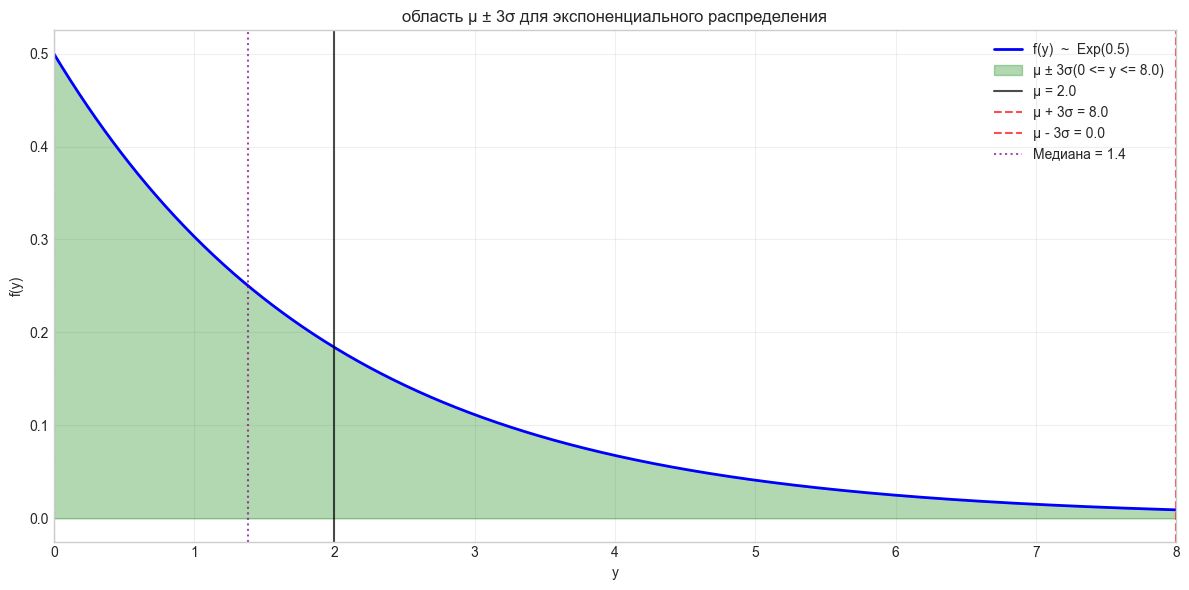

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_values, exp_dist.pdf(y_values), 'b-', linewidth=2, label=f'f(y)  ~  Exp({LAMBDA})')

#заливаем область μ ± 3σ
y_fill = y_values[(y_values >= lower_bound) & (y_values <= upper_bound)]
ax.fill_between(y_fill, 0, exp_dist.pdf(y_fill), color='g', alpha=0.3, label=f'μ ± 3σ({lower_bound} <= y <= {upper_bound})')

#вертикальные линии для границ
ax.axvline(mean_y, color='black', linestyle='-', alpha=0.7, label=f'μ = {mean_y}')
ax.axvline(upper_bound, color='red', linestyle='--', alpha=0.7, label=f'μ + 3σ = {upper_bound:.1f}')
ax.axvline(lower_bound, color='red', linestyle='--', alpha=0.7, label=f'μ - 3σ = {lower_bound:.1f}')

#отмечаем медиану (особенность экспоненциального распределения)
median_y = np.log(2) / LAMBDA
ax.axvline(median_y, color='purple', linestyle=':', alpha=0.7, label=f'Медиана = {median_y:.1f}')
ax.set_title('область μ ± 3σ для экспоненциального распределения')
ax.set_xlabel('y')
ax.set_ylabel('f(y)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 8)
plt.tight_layout()
plt.show()

сравнение с норм распределением

In [40]:
# Вероятность попадания в интервал μ ± 3σ
prob_3sigma_exp = exp_dist.cdf(upper_bound) - exp_dist.cdf(lower_bound)

print("сравнение правила 3-х сигм для разных распределений:")
print(f"{'Параметр':<25} {'Нормальное':<15} {'Экспоненциальное':<15}")
print(f"{'M[x]':<25} {MX:<15} {mean_y:<15}")
print(f"{'σ':<25} {SIGMA:<15} {std_y:<15}")
print(f"{'μ - 3σ':<25} {MX-3*SIGMA:<15.1f} {lower_bound:<15.2f}")
print(f"{'μ + 3σ':<25} {MX+3*SIGMA:<15.1f} {upper_bound:<15.2f}")
print(f"{'P(μ-3σ < X < μ+3σ)':<25} {0.9973:<15} {prob_3sigma_exp:<15}")

print(f"Для нормального распределения: P(μ-3σ < X < μ+3σ) ≈ 0.9973 (99.73%)")
print(f"Для экспоненциального: P(μ-3σ < Y < μ+3σ) = {prob_3sigma_exp:.4f} ({prob_3sigma_exp*100:.1f}%)")
print(f"Разница: {abs(0.9973 - prob_3sigma_exp):.4f}")
print(f"Правило '3-сигм' для экспоненциального распределения дает {prob_3sigma_exp*100:.1f}% вместо 99.73%")
print(f"Это связано с асимметричностью экспоненциального распределения")


сравнение правила 3-х сигм для разных распределений:
Параметр                  Нормальное      Экспоненциальное
M[x]                      10              2.0            
σ                         2.0             2.0            
μ - 3σ                    4.0             0.00           
μ + 3σ                    16.0            8.00           
P(μ-3σ < X < μ+3σ)        0.9973          0.9816843611112658
Для нормального распределения: P(μ-3σ < X < μ+3σ) ≈ 0.9973 (99.73%)
Для экспоненциального: P(μ-3σ < Y < μ+3σ) = 0.9817 (98.2%)
Разница: 0.0156
Правило '3-сигм' для экспоненциального распределения дает 98.2% вместо 99.73%
Это связано с асимметричностью экспоненциального распределения
